In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels as stats
from scipy import stats
color_pal = sns.color_palette()
plt.style.use("ggplot")

In [7]:
titanic = sns.load_dataset("titanic")
iris = sns.load_dataset("iris")

In [8]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [9]:
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


# Normal Distribution
## Largely seen in the nature has 4 statistical methods (mean,standard deviation,skewness,kurtosis)
## it follows Emperical Rule i.e (68%,95%,99.91%) data is covered in increasing standard deviation simultoneously
## Here the random variable is continuous i.e pdf and cdf exist


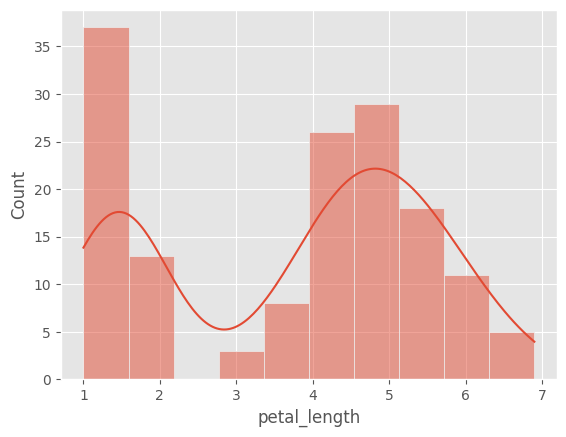

In [15]:
## Normal Distribution
## Visualization (by seeing)
sns.histplot(data=iris,x="petal_length",bins=10,kde=True)
plt.show()
## it is bi modal distribution

In [17]:
## Lets create and normal distribution
normal_dist = np.random.normal(loc=29,scale=1,size=(1000))
normal_dist.shape

(1000,)

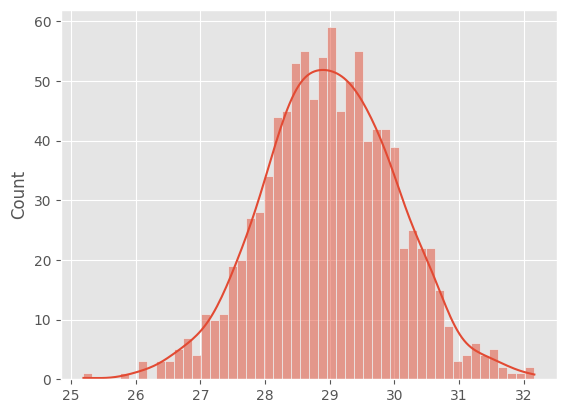

In [18]:
sns.histplot(normal_dist,bins=50,kde=True)
plt.show()

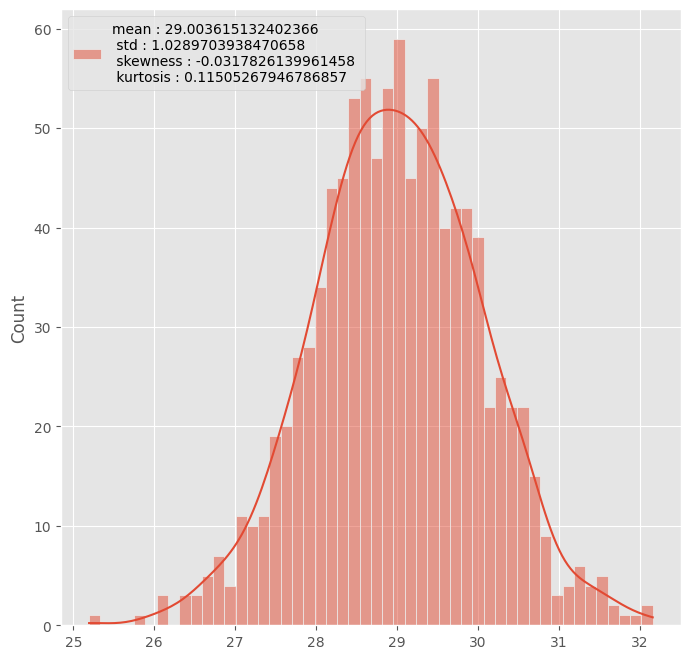

In [31]:
## Four Statistical Method of normal distribution
mean = normal_dist.mean()
std = normal_dist.std()
skewness = stats.skew(normal_dist)
kurtosis = stats.kurtosis(normal_dist)
labels = f"mean : {mean} \n std : {std} \n skewness : {skewness} \n kurtosis : {kurtosis}"
fig, ax = plt.subplots(figsize=(8,8))
sns.histplot(normal_dist,bins=50,kde=True,label=labels,legend=True,ax=ax)
plt.legend()
plt.show()

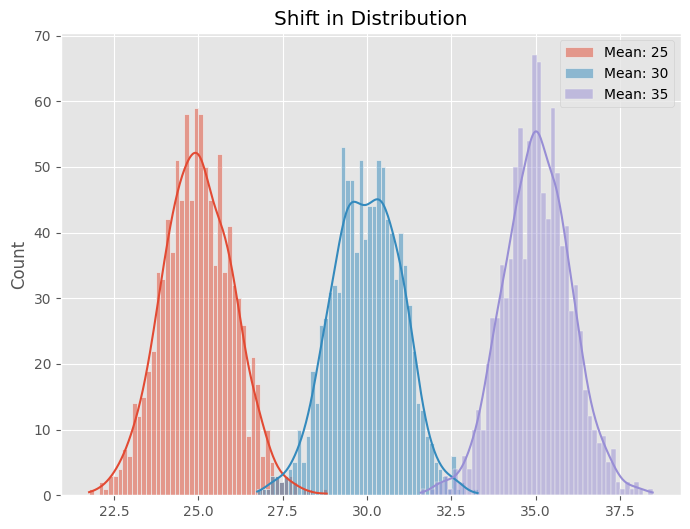

In [34]:
### Mean
## Fisrt and important statistical method increase in mean shift the distribution
## mean increase = distribution shift to right
## mean decreases = distribution shift to left
fig,ax = plt.subplots(figsize=(8,6))
locs = [25,30,35]
for loc in locs:
  normal_dist = np.random.normal(loc=loc,scale=1,size=1000)
  sns.histplot(normal_dist,bins=50,kde=True,ax=ax,label=f"Mean: {loc}")
plt.legend()
plt.title("Shift in Distribution")
plt.show()


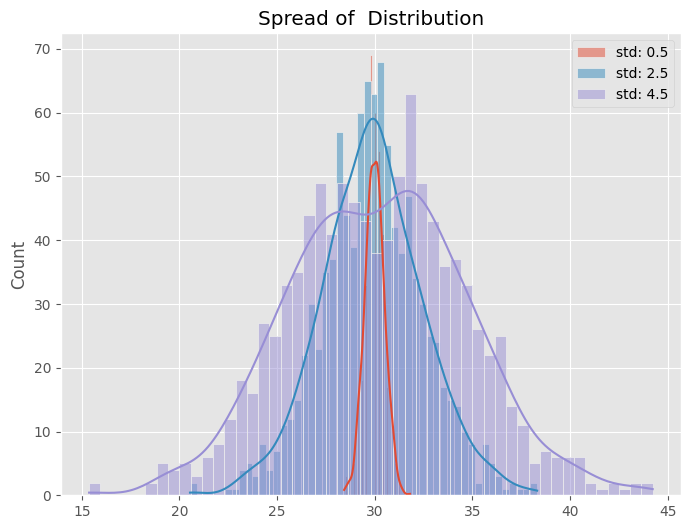

In [37]:
## Standard Distribution
## Second Statistical Method that decide the spread of the distribution
## increase in std = the curve flatten i.e the curve spreads
## decrease in std = the curve get peak i.e the curve get sharpen
fig,ax = plt.subplots(figsize=(8,6))
scales = [0.5,2.5,4.5]
for scale in scales:
  normal_dist = np.random.normal(loc=30,scale=scale,size=1000)
  sns.histplot(normal_dist,bins=50,kde=True,ax=ax,label=f"std: {scale}")
plt.legend()
plt.title("Spread of  Distribution")
plt.show()

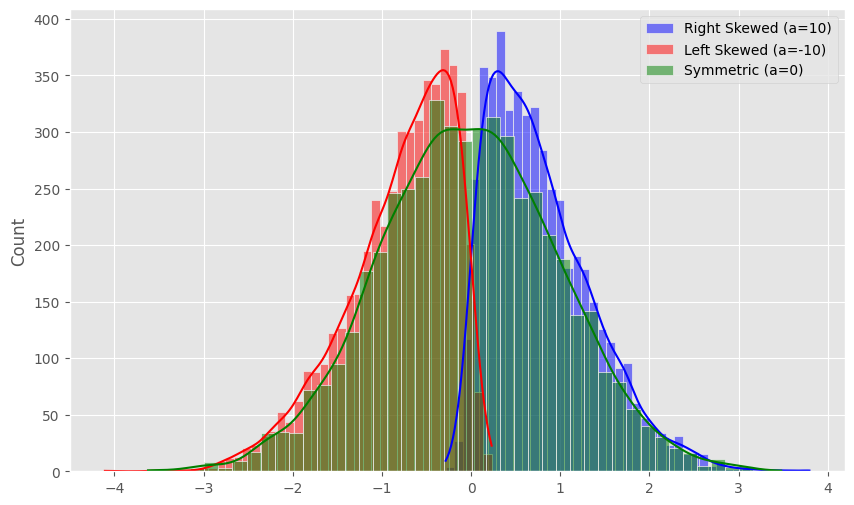

In [39]:
## Skewness
## third statistical method that show how much or data is skewed
## increase in a(skew) = tail on left side => left skewed
## decrease in skew = tail on right side => right skewed
## skew == 0 i.e normal distribution or uniform distribution
from scipy.stats import skewnorm, skew
# 1. Generate distributions
size = 5000
# Right skewed: Positive 'a'
right_skewed = skewnorm.rvs(a=10, size=size)
# Left skewed: Negative 'a'
left_skewed = skewnorm.rvs(a=-10, size=size)
# Symmetric: a=0
symmetric = skewnorm.rvs(a=0, size=size)

# 2. Visualize
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(right_skewed, kde=True, color='blue', label='Right Skewed (a=10)', ax=ax)
sns.histplot(left_skewed, kde=True, color='red', label='Left Skewed (a=-10)', ax=ax)
sns.histplot(symmetric, kde=True, color='green', label='Symmetric (a=0)', ax=ax)

plt.legend()
plt.show()


-0.011625778598957304


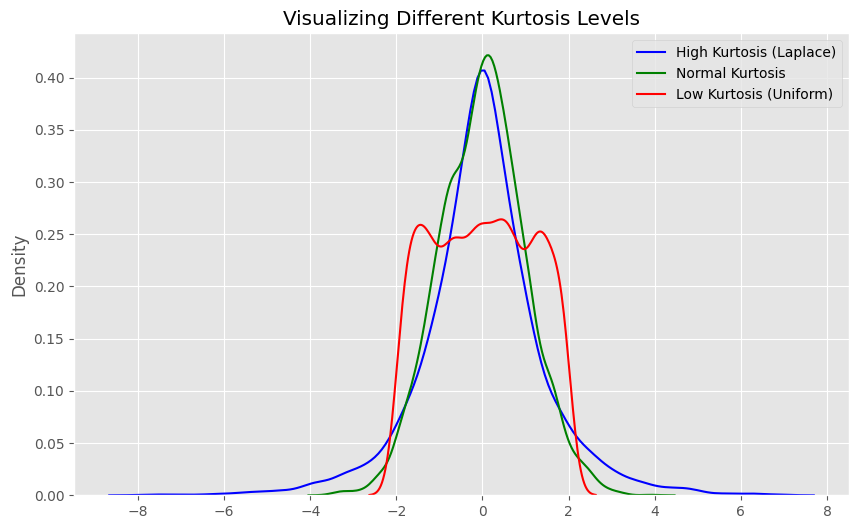

In [40]:
## Kurtosis
## 4th statistical method use to check the taildness of the distribution i.e higher the tail i.e the more high probability of event to occurr (in low or extreme)
kurtosis = stats.kurtosis(normal_dist)
print(kurtosis)
## Excess kurtosis
## it is the kurtosis of the normal distribution
## formula = normal dist_kurtosis - 3
## Divided in 3 types
## 1. LeptoKurtic - Excess kurtosis > 0
## 2. Platykurtic - Excess kurtosis < 0
## mesokurtic - Excess kurtosis == 0
from scipy.stats import laplace, norm, uniform, kurtosis

size = 5000

# 1. Generate distributions
# High Kurtosis (Leptokurtic) - Use Laplace
high_kurt = laplace.rvs(loc=0, scale=1, size=size)
# Normal Kurtosis (Mesokurtic) - Use Normal
normal_kurt = norm.rvs(loc=0, scale=1, size=size)
# Low Kurtosis (Platykurtic) - Use Uniform
low_kurt = uniform.rvs(loc=-2, scale=4, size=size)

plt.figure(figsize=(10, 6))
sns.kdeplot(high_kurt, label="High Kurtosis (Laplace)", color="blue")
sns.kdeplot(normal_kurt, label="Normal Kurtosis", color="green")
sns.kdeplot(low_kurt, label="Low Kurtosis (Uniform)", color="red")
plt.title("Visualizing Different Kurtosis Levels")
plt.legend()
plt.show()



From above see the tail events for low very less possibility of tail events

## Standard Normal Distribution
## It is an variant of normal distribution with mean = 0 and std = 1
## X ~ Normal (mean=0,std=1)


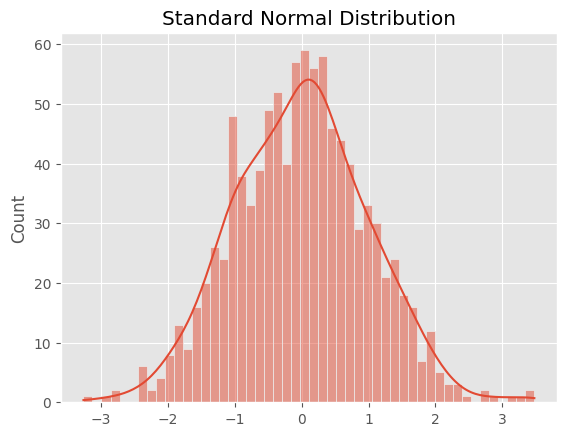

In [41]:
standard_normal = np.random.standard_normal(size=(1000))
sns.histplot(standard_normal,bins=50,kde=True)
plt.title("Standard Normal Distribution")
plt.show()